# Task 10.3 D
### Name: Nay Tun
### Student Id: 225110052

# 1. Load the MINIST data set, randomly sample 20% as the labelled set, 70% as unlabelled set and the rest 10% as the test set.

In [6]:
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

## Load the data from sklearn library
## Previous assignment in 10.2C I actually loaded this data from Keras which already splits Train/Test
## But for this purpose we need the whole data set to randomly split to 20%/70%/10%

In [55]:
mnist = fetch_openml('mnist_784', as_frame=False)
X = mnist.data.astype(np.float32) / 255 # scaled 0 to 1 by dividing with 255
y = mnist.target.astype(int)

In [56]:
N  = len(X) # total rows
n_lab = int(N * .2)
n_unlab = int(N * .7)
n_test = N - n_lab - n_unlab

print (f"n_lab:{n_lab}, n_unlab:{n_unlab}, n_test:{n_test}")

n_lab:14000, n_unlab:49000, n_test:7000


## Have to randomized the indexes

In [58]:
r  = np.random.RandomState(99)
p = r.permutation(N)

idx_lab  = p[:n_lab]
idx_unlab  = p[n_lab : n_lab + n_unlab]
idx_test = p[n_lab + n_unlab :]
print (idx_lab, idx_unlab, idx_test)

[ 5406 53858 30647 ... 26271 24219 28421] [ 5214 61430 28869 ... 12798 40209 51945] [58775 47108 58027 ... 46265 23587 29313]


In [59]:
X_lab,  y_lab  = X[idx_lab],  y[idx_lab]
X_unlab,  y_unlab  = X[idx_unlab],  y[idx_unlab]   
X_test, y_test = X[idx_test], y[idx_test]

print(f"Labeled   : {len(X_lab):,}  (20%)")
print(f"Unlabeled : {len(X_unlab):,}  (70%)")
print(f"Test      : {len(X_test):,}  (10%)")

Labeled   : 14,000  (20%)
Unlabeled : 49,000  (70%)
Test      : 7,000  (10%)


# 2.  Train a feed forward neural net on the above 20% labelled training set, run  self-training with the 70% unlabelled set. Can you get a converged model? If yes report the number of iterations you run with self training, if not improve the percentage of the labelled set and repeat the self training process until you can get a converged model. Report the final model performance with key findings.

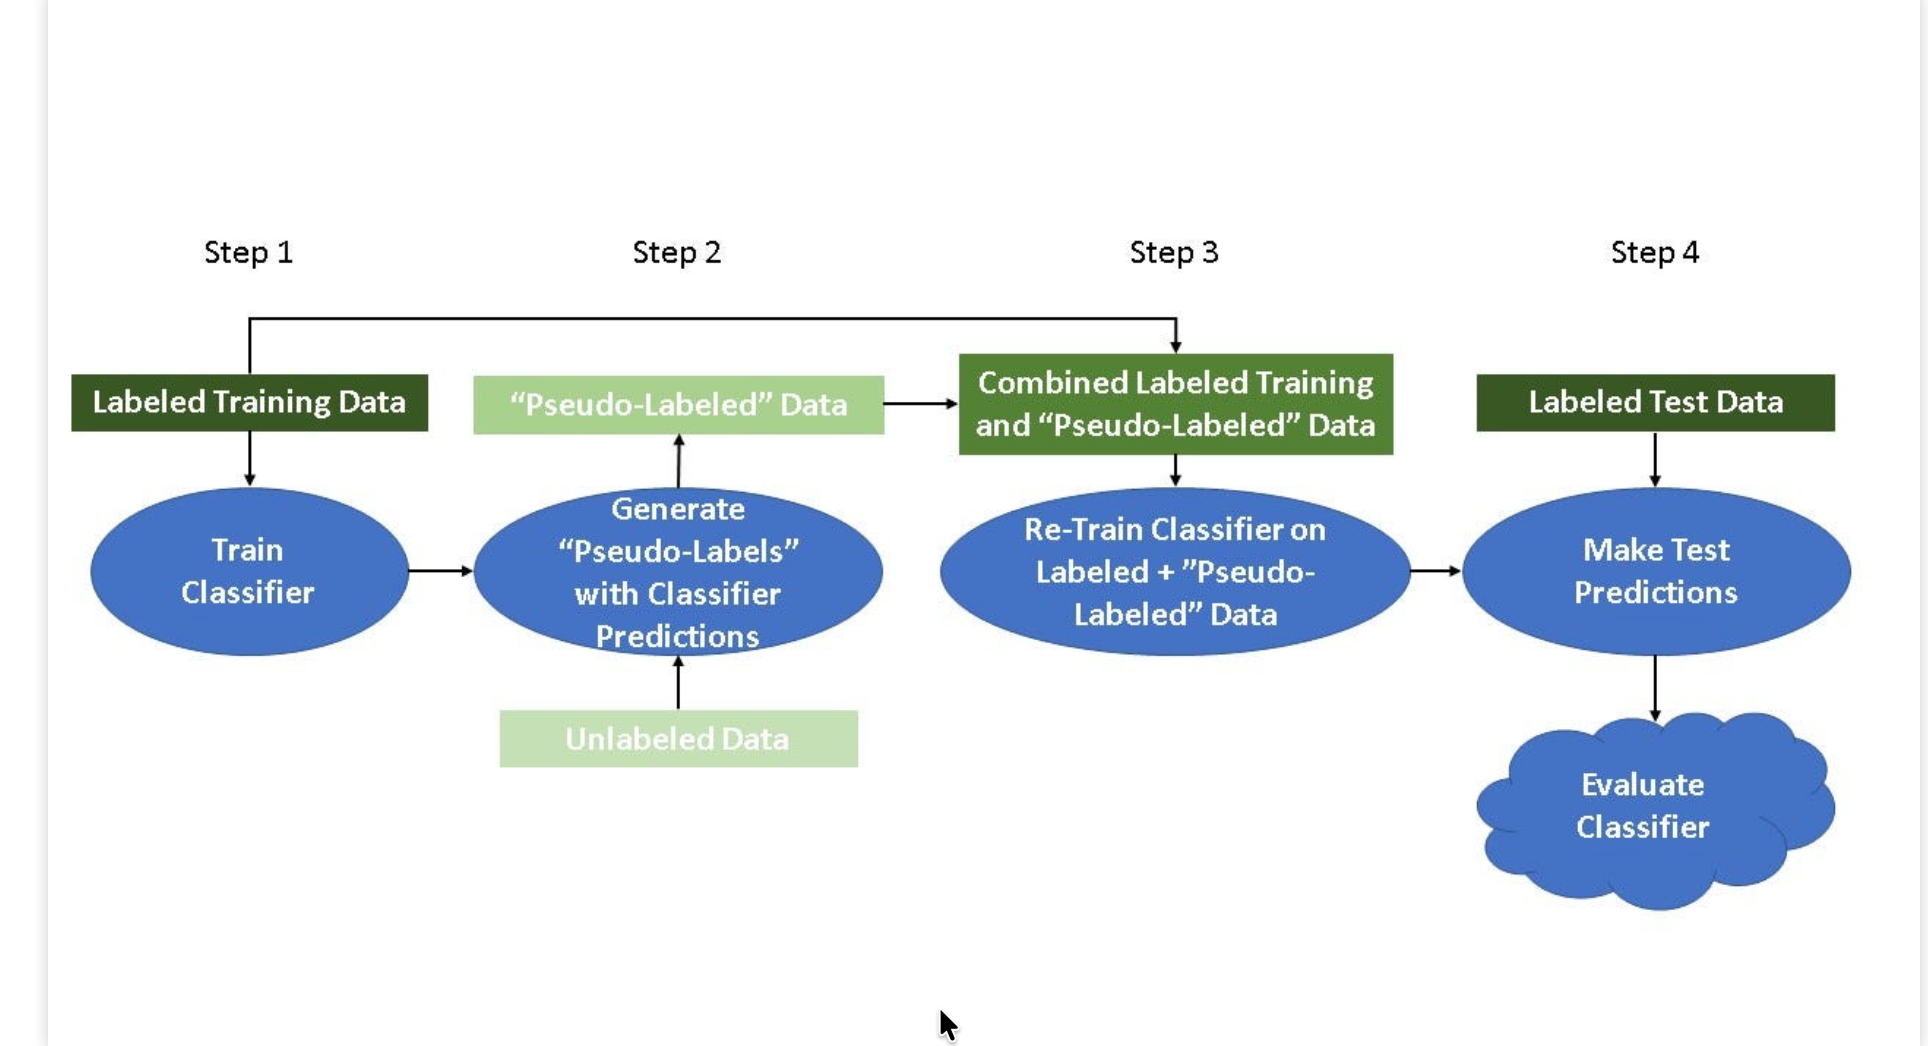

## have to follow these steps, helps me visualize what I need to do

## Starts with the label data

In [60]:
X_cur = X_lab.copy()
y_cur = y_lab.copy()
X_pool = X_unlab.copy()
y_pool = y_unlab.copy()

In [61]:
neurons = 250
model_mlp = MLPClassifier(
        hidden_layer_sizes=(neurons) * 2
        , activation="relu" # need this so it is a linear model
        , early_stopping=False # need this so it doesn't internally swith random splits
        ,random_state=1
        ,max_iter=100
)
model_mlp.fit(X_cur, y_cur)
prev_acc   = accuracy_score(y_test, model_mlp.predict(X_test))
converged  = False
print (prev_acc)

0.9674285714285714


## Some initial Variables before the loop
- Declare confidence threshold
- Declare Max interations (how many times we loop)
- Declare convergence THRESHOLD (delta accuracy < CONVERGENCE_THRESHOLD (0.001))

In [62]:
CONF_THRESHOLD  = 0.99   # keep predictions where max prob >= this
MAX_ITERATIONS  = 20     # safety cap
CONVERGENCE_THRESHOLD = 0.001  # |Δacc| < this → converged

## Now lets do the loop

In [63]:
for i in range(1, MAX_ITERATIONS +1 ):
    if len(X_pool) ==0:
        print ("Pool is empty")
        break
    proba = model_mlp.predict_proba(X_pool)
    mask = proba.max(axis=1) >= CONVERGENCE_THRESHOLD
    pseudo_lbl = proba.argmax(axis=1)
    
    if mask.sum() == 0:
        print ("No confident samples found")
        break
    # now stack the data from the pool which meets the threshold on top of X_cur
    X_cur = np.vstack([X_cur, X_pool[mask]])
    y_cur = np.hstack([y_cur, pseudo_lbl[mask]])
    X_pool = X_pool[~mask] # remove the rows that were stacked to X_cur from the pool
    y_pool = y_pool[~mask]
    model_mlp = MLPClassifier(
        hidden_layer_sizes=(neurons) * 2
        , activation="relu" # need this so it is a linear model
        , early_stopping=False # need this so it doesn't internally swith random splits
        ,random_state=1
        ,max_iter=300
    )
    model_mlp.fit(X_cur, y_cur)
    acc   = accuracy_score(y_test, model_mlp.predict(X_test))
    if abs(acc - prev_acc) < CONVERGENCE_THRESHOLD:
        print(f"Converged at iteration {iteration}")
        break # exit the lopp because converged
    prev_acc = acc # set it up for the next loop
    
    

Pool is empty


## Ok I can't figure it out Pool is always becoming empty never converged


# 3.  Given the same setup, apart from self training, run another semi-supervised learning algorithm, compare the results and explain your key findings. 
# 4.  For the above two semi-supervised learning algorithms, do both quantitive and human error analysis on the wrong pseudo labels.

### Ok I give up could not get the loop to work and I am lacking in my knowledge to confidently answer these questions
### I also don't feel it is not right to use an LLM and answer something I am still trying to learn
### I have given it my best a try and the rest is up to fate